# imports, etc.

In [14]:
from pathlib import Path
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns

In [15]:
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()

    markers = [
        "single_point_mutations.tsv",
        "results",
        "assets",
    ]

    for path in [start] + list(start.parents):
        if all((path / marker).exists() for marker in markers):
            return path

    raise FileNotFoundError(
        "Could not find project root. Please run this notebook from inside the aml-final-project repo."
    )

PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "results"
XGB_RESULTS_DIR = RESULTS_DIR / "xgboost"
ASSETS_DIR = PROJECT_ROOT / "assets"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_DIR exists:", RESULTS_DIR.exists())
print("ASSETS_DIR exists:", ASSETS_DIR.exists())

PROJECT_ROOT: /Users/zoyakhan/Documents/GitHub/aml-final-project
RESULTS_DIR exists: True
ASSETS_DIR exists: True


# preliminary data exploration plots

### 1. Load TSV + rebuild df used for prelim. analysis

In [16]:
PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "single_point_mutations.tsv"

table = pd.read_csv(DATA_PATH, sep="\t")

table["TYPE"] = [
    "PDB" if "PDB" in str(x) else "UniProt" if "UniProt" in str(x) else "Unknown"
    for x in table["MUTATION"]
]
table = table[table["TYPE"] != "Unknown"].copy()

table_uniprot = table[table["TYPE"] == "UniProt"].copy()

aa_properties = {
    "A": {"hydrophobicity": 0.61, "charge": 0, "weight": 89.09},
    "R": {"hydrophobicity": 0.60, "charge": 1, "weight": 174.20},
    "N": {"hydrophobicity": 0.06, "charge": 0, "weight": 132.12},
    "D": {"hydrophobicity": 0.46, "charge": -1, "weight": 133.10},
    "C": {"hydrophobicity": 1.07, "charge": 0, "weight": 121.15},
    "Q": {"hydrophobicity": 0.00, "charge": 0, "weight": 146.15},
    "E": {"hydrophobicity": 0.47, "charge": -1, "weight": 147.13},
    "G": {"hydrophobicity": 0.07, "charge": 0, "weight": 75.07},
    "H": {"hydrophobicity": 0.61, "charge": 0, "weight": 155.16},
    "I": {"hydrophobicity": 2.22, "charge": 0, "weight": 131.17},
    "L": {"hydrophobicity": 1.53, "charge": 0, "weight": 131.17},
    "K": {"hydrophobicity": 1.15, "charge": 1, "weight": 146.19},
    "M": {"hydrophobicity": 1.18, "charge": 0, "weight": 149.21},
    "F": {"hydrophobicity": 2.02, "charge": 0, "weight": 165.19},
    "P": {"hydrophobicity": 1.95, "charge": 0, "weight": 115.13},
    "S": {"hydrophobicity": 0.05, "charge": 0, "weight": 105.09},
    "T": {"hydrophobicity": 0.05, "charge": 0, "weight": 119.12},
    "W": {"hydrophobicity": 2.65, "charge": 0, "weight": 204.24},
    "Y": {"hydrophobicity": 1.88, "charge": 0, "weight": 181.19},
    "V": {"hydrophobicity": 1.32, "charge": 0, "weight": 117.15},
}

table_uniprot_xgb = table_uniprot.copy()
table_uniprot_xgb["WT_AA"] = table_uniprot_xgb["MUTATION"].apply(lambda x: str(x).split()[0][0])
table_uniprot_xgb["MUT_AA"] = table_uniprot_xgb["MUTATION"].apply(lambda x: str(x).split()[0][-1])
table_uniprot_xgb["POSITION"] = table_uniprot_xgb["MUTATION"].apply(lambda x: int(str(x).split()[0][1:-1]))

table_uniprot_xgb = table_uniprot_xgb[
    table_uniprot_xgb["WT_AA"].isin(aa_properties) &
    table_uniprot_xgb["MUT_AA"].isin(aa_properties)
].copy()

table_uniprot_xgb["delta_hydrophobicity"] = table_uniprot_xgb.apply(
    lambda row: aa_properties[row["MUT_AA"]]["hydrophobicity"] - aa_properties[row["WT_AA"]]["hydrophobicity"],
    axis=1,
)
table_uniprot_xgb["delta_charge"] = table_uniprot_xgb.apply(
    lambda row: aa_properties[row["MUT_AA"]]["charge"] - aa_properties[row["WT_AA"]]["charge"],
    axis=1,
)
table_uniprot_xgb["delta_weight"] = table_uniprot_xgb.apply(
    lambda row: aa_properties[row["MUT_AA"]]["weight"] - aa_properties[row["WT_AA"]]["weight"],
    axis=1,
)

table_uniprot_xgb["∆∆G_(kcal/mol)"] = pd.to_numeric(table_uniprot_xgb["∆∆G_(kcal/mol)"], errors="coerce")
table_uniprot_xgb = table_uniprot_xgb.dropna(subset=["∆∆G_(kcal/mol)"]).copy()

one_hot_wt = pd.get_dummies(table_uniprot_xgb["WT_AA"], prefix="WT")
one_hot_mut = pd.get_dummies(table_uniprot_xgb["MUT_AA"], prefix="MUT")
table_uniprot_xgb = pd.concat([table_uniprot_xgb, one_hot_wt, one_hot_mut], axis=1)

print("table_uniprot_xgb shape:", table_uniprot_xgb.shape)
print("unique proteins:", table_uniprot_xgb["PROTEIN"].nunique())
display(table_uniprot_xgb.head())

table_uniprot_xgb shape: (496, 66)
unique proteins: 46


,NO,PROTEIN,UniProt_ID,MUTATION,SOURCE,PDB_wild,PDB_Chain_Mutation,SEC_STR,ASA,pH,...,MUT_M,MUT_N,MUT_P,MUT_Q,MUT_R,MUT_S,MUT_T,MUT_V,MUT_W,MUT_Y
0,176,Villin-1,P02640,D44N (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,3.0,...,False,True,False,False,False,False,False,False,False,False
1,177,Villin-1,P02640,E795Q (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,3.0,...,False,False,False,True,False,False,False,False,False,False
2,178,Villin-1,P02640,D796N (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,3.0,...,False,True,False,False,False,False,False,False,False,False
3,179,Villin-1,P02640,E822Q (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,3.0,...,False,False,False,True,False,False,False,False,False,False
4,181,Villin-1,P02640,D44N (UniProt),Gallus gallus (Chicken),1YRF,-,-,NaN,6.0,...,False,True,False,False,False,False,False,False,False,False


### 2. ΔΔG distribution

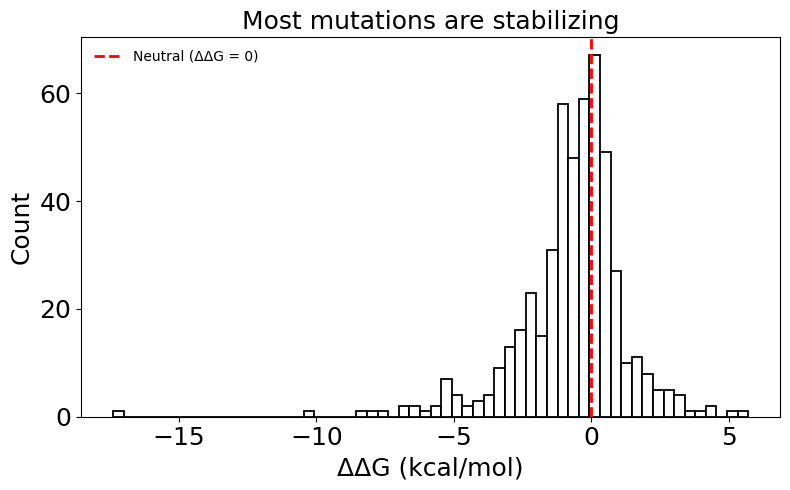

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    table_uniprot_xgb["∆∆G_(kcal/mol)"],
    bins=60,
    edgecolor="black",
    linewidth=1.3,
    color="white",
)

ax.axvline(0, color="red", linestyle="--", linewidth=2, label="Neutral (ΔΔG = 0)")
ax.set_xlabel("ΔΔG (kcal/mol)", fontsize=18)
ax.set_ylabel("Count", fontsize=18)
ax.tick_params(axis="both", labelsize=18)
ax.set_title("Most mutations are stabilizing", fontsize=18)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

### 3. Substitution heatmap

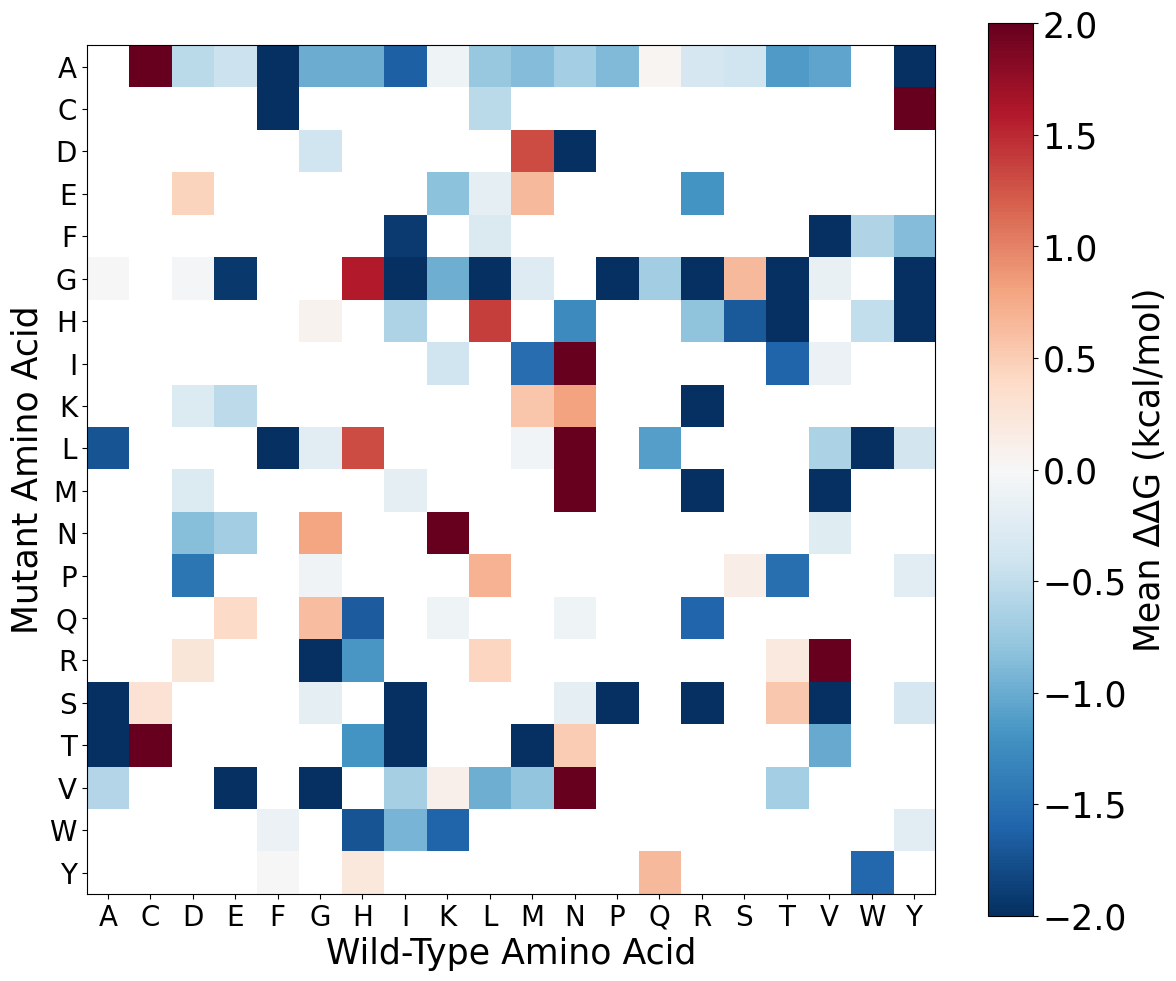

In [18]:
amino_acids = sorted(set(table_uniprot_xgb["WT_AA"]).union(set(table_uniprot_xgb["MUT_AA"])))
matrix = pd.DataFrame(index=amino_acids, columns=amino_acids, dtype=float)

for mut in amino_acids:
    for wt in amino_acids:
        subset = table_uniprot_xgb[
            (table_uniprot_xgb["WT_AA"] == wt) &
            (table_uniprot_xgb["MUT_AA"] == mut)
        ]["∆∆G_(kcal/mol)"]
        matrix.loc[mut, wt] = subset.mean() if len(subset) > 0 else np.nan

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(matrix.values.astype(float), cmap="RdBu_r", vmin=-2, vmax=2)

ax.set_xticks(range(len(amino_acids)))
ax.set_yticks(range(len(amino_acids)))
ax.set_xticklabels(amino_acids, fontsize=20)
ax.set_yticklabels(amino_acids, fontsize=20)

ax.set_xlabel("Wild-Type Amino Acid", fontsize=25)
ax.set_ylabel("Mutant Amino Acid", fontsize=25)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean ΔΔG (kcal/mol)", fontsize=25)
cbar.ax.tick_params(labelsize=25)

plt.tight_layout()
plt.show()

### 4. Charge-change boxplot

/var/folders/gd/_r05n4z510b8fwkl302p302w0000gn/T/ipykernel_53615/558611072.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, fontsize=13)


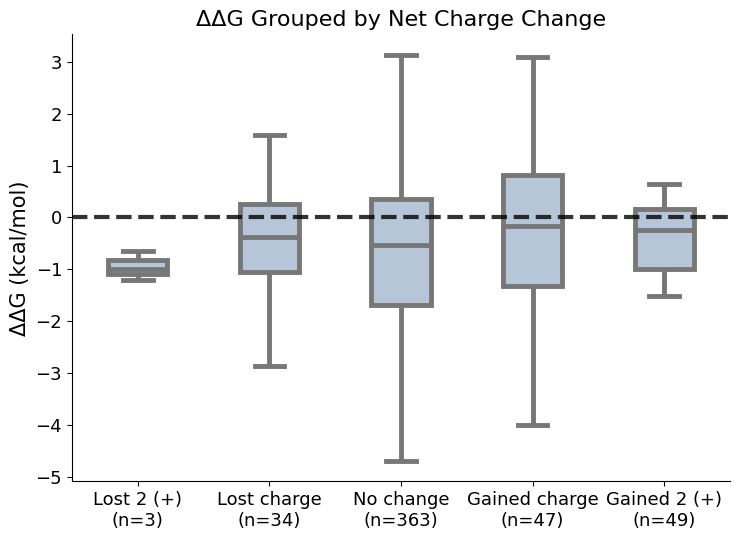

In [19]:
charge_labels = {
    -2: "Lost 2 (+)",
    -1: "Lost charge",
    0: "No change",
    1: "Gained charge",
    2: "Gained 2 (+)",
}
charge_order = [-2, -1, 0, 1, 2]

plot_df = table_uniprot_xgb[["delta_charge", "∆∆G_(kcal/mol)"]].copy()
plot_df = plot_df[plot_df["delta_charge"].isin(charge_order)].copy()

counts = plot_df["delta_charge"].value_counts().reindex(charge_order).fillna(0).astype(int)
tick_labels = [f"{charge_labels[k]}\n(n={counts[k]})" for k in charge_order]

plot_df["Charge Category"] = pd.Categorical(plot_df["delta_charge"], categories=charge_order, ordered=True)

fig, ax = plt.subplots(figsize=(7.5, 5.5))

sns.boxplot(
    data=plot_df,
    x="Charge Category",
    y="∆∆G_(kcal/mol)",
    order=charge_order,
    width=0.45,
    showfliers=False,
    ax=ax,
    color="lightsteelblue",
    linewidth=3.5,
)

ax.axhline(0, color="black", linestyle="--", linewidth=3, alpha=0.8)
ax.set_xticklabels(tick_labels, fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("ΔΔG (kcal/mol)", fontsize=15)
ax.set_title("ΔΔG Grouped by Net Charge Change", fontsize=16)
ax.tick_params(axis="y", labelsize=13)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### 5. Feature-correlation heatmap

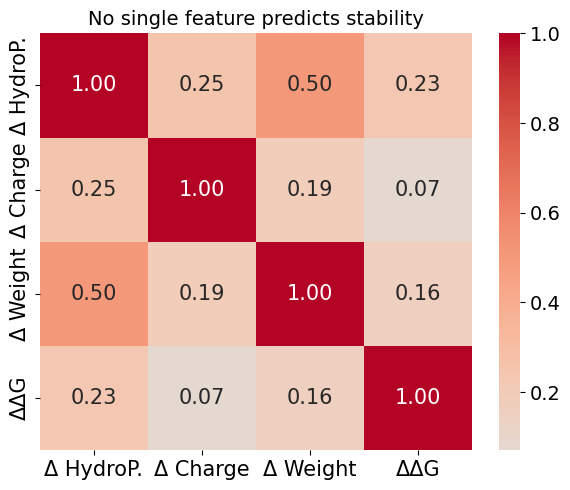

In [20]:
features = ["delta_hydrophobicity", "delta_charge", "delta_weight", "∆∆G_(kcal/mol)"]
corr = table_uniprot_xgb[features].corr()

fig, ax = plt.subplots(figsize=(6, 5))

hm = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    annot_kws={"size": 15},
    xticklabels=["Δ HydroP.", "Δ Charge", "Δ Weight", "ΔΔG"],
    yticklabels=["Δ HydroP.", "Δ Charge", "Δ Weight", "ΔΔG"],
    ax=ax,
)

ax.set_title("No single feature predicts stability", fontsize=14)
ax.tick_params(axis="both", labelsize=15)

cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()

# XGBoost baseline plots

### 1. Load saved XGBoost outputs

In [21]:
PROJECT_ROOT = Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results"
XGB_RESULTS_DIR = RESULTS_DIR / "xgboost"
ASSETS_DIR = PROJECT_ROOT / "assets"

XGB_RUN_TAG = "xgb_prototype"

xgb_metrics = pd.read_csv(XGB_RESULTS_DIR / f"xgb_split_metrics_{XGB_RUN_TAG}.csv")
xgb_predictions = pd.read_csv(XGB_RESULTS_DIR / f"xgb_predictions_{XGB_RUN_TAG}.csv")
xgb_training_curves = pd.read_csv(XGB_RESULTS_DIR / f"xgb_training_curves_{XGB_RUN_TAG}.csv")
xgb_feature_importance = pd.read_csv(XGB_RESULTS_DIR / f"xgb_feature_importance_{XGB_RUN_TAG}.csv")
xgb_hyperparameter_search = pd.read_csv(XGB_RESULTS_DIR / f"xgb_hyperparameter_search_{XGB_RUN_TAG}.csv")

best_config_path = XGB_RESULTS_DIR / f"xgb_best_config_{XGB_RUN_TAG}.json"
if best_config_path.exists():
    with open(best_config_path, "r") as f:
        xgb_best_config = json.load(f)
else:
    xgb_best_config = None

print("Loaded XGBoost files:")
print("metrics:", xgb_metrics.shape)
print("predictions:", xgb_predictions.shape)
print("training curves:", xgb_training_curves.shape)
print("feature importance:", xgb_feature_importance.shape)
print("hyperparameter search:", xgb_hyperparameter_search.shape)

display(xgb_metrics)
display(xgb_hyperparameter_search)

Loaded XGBoost files:
metrics: (6, 10)
predictions: (992, 52)
training curves: (274, 5)
feature importance: (86, 3)
hyperparameter search: (5, 6)


,model,split_strategy,set,rmse,r,n,best_iteration,max_depth,learning_rate,n_estimators
0,XGBoost,Per-Mutation,train,1.582088,0.731667,282,29,6,0.05,300
1,XGBoost,Per-Mutation,val,1.616716,0.425898,95,29,6,0.05,300
2,XGBoost,Per-Mutation,test,1.775668,0.396912,119,29,6,0.05,300
3,XGBoost,Protein-Level,train,1.021302,0.754311,275,36,6,0.05,300
4,XGBoost,Protein-Level,val,3.128982,0.092027,123,36,6,0.05,300
5,XGBoost,Protein-Level,test,1.805585,0.198781,98,36,6,0.05,300


,max_depth,learning_rate,n_estimators,val_r,val_rmse,best_iteration
0,3,0.05,300,0.402764,1.638186,61
1,4,0.05,300,0.425804,1.617409,35
2,6,0.05,300,0.425898,1.616716,29
3,4,0.01,300,0.418368,1.622493,206
4,4,0.10,300,0.414649,1.631258,27


### 2. 4-panel XGBoost comparison

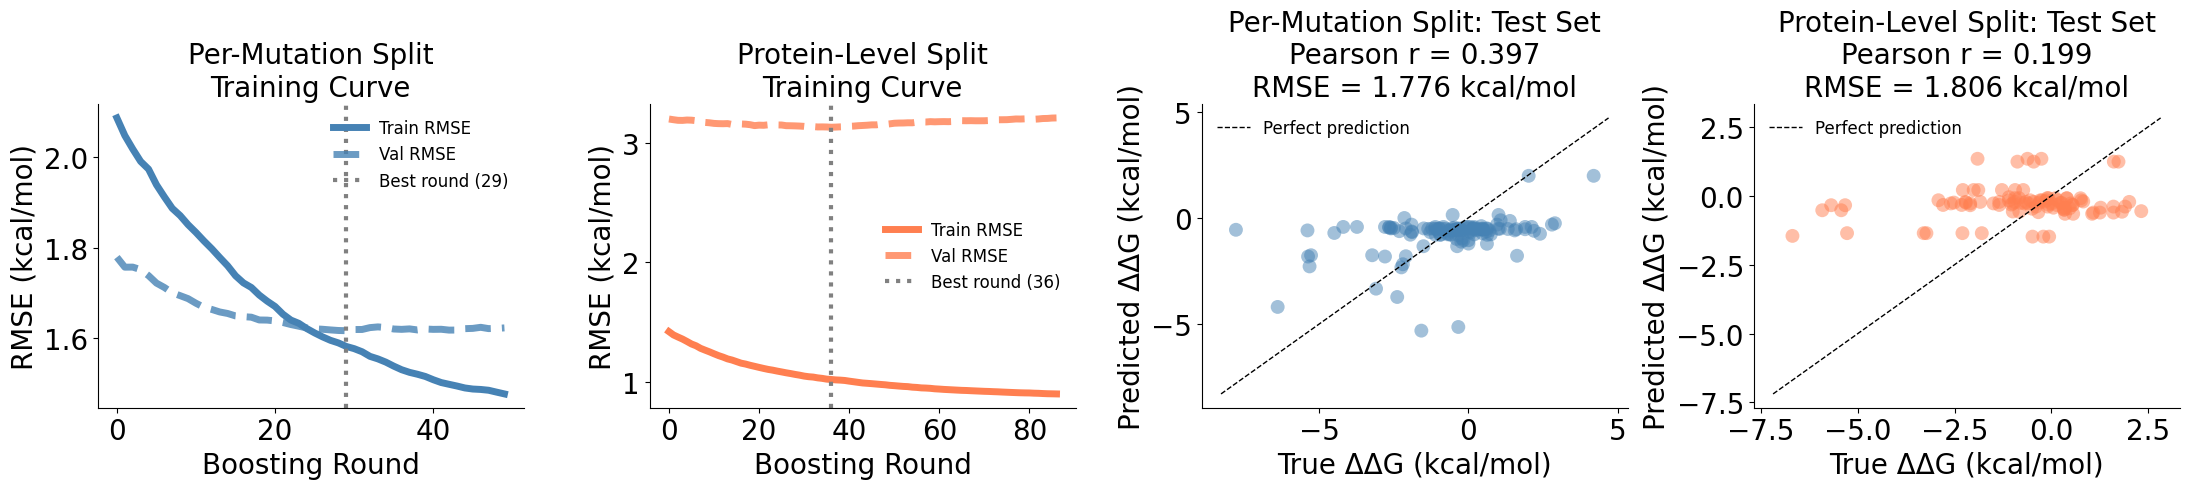

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

colors = {"Per-Mutation": "steelblue", "Protein-Level": "coral"}

for i, (split_name, col) in enumerate(colors.items()):
    ax = axes[i]

    train_curve = (
        xgb_training_curves[
            (xgb_training_curves["split_strategy"] == split_name) &
            (xgb_training_curves["set"] == "train")
        ]
        .sort_values("epoch")
    )

    val_curve = (
        xgb_training_curves[
            (xgb_training_curves["split_strategy"] == split_name) &
            (xgb_training_curves["set"] == "val")
        ]
        .sort_values("epoch")
    )

    best_round = int(train_curve["best_iteration"].dropna().iloc[0])

    ax.plot(train_curve["epoch"], train_curve["rmse"], color=col, linestyle="-", label="Train RMSE", linewidth=5)
    ax.plot(val_curve["epoch"], val_curve["rmse"], color=col, linestyle="--", label="Val RMSE", linewidth=5, alpha=0.8)
    ax.axvline(best_round, color="gray", linestyle=":", linewidth=3, label=f"Best round ({best_round})")

    ax.set_xlabel("Boosting Round", fontsize=20)
    ax.set_ylabel("RMSE (kcal/mol)", fontsize=20)
    ax.set_title(f"{split_name} Split\nTraining Curve", fontsize=20)
    ax.legend(fontsize=12, frameon=False)
    ax.tick_params(axis="both", labelsize=20)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for i, (split_name, col) in enumerate(colors.items()):
    ax = axes[i + 2]

    test_preds = (
        xgb_predictions[
            (xgb_predictions["split_strategy"] == split_name) &
            (xgb_predictions["set"] == "test")
        ]
        .copy()
        .reset_index(drop=True)
    )

    y_true = test_preds["y_true"].to_numpy(dtype=float)
    y_pred = test_preds["y_pred"].to_numpy(dtype=float)

    r = pearsonr(y_true, y_pred)[0] if len(y_true) > 2 else np.nan
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

    ax.scatter(y_true, y_pred, alpha=0.5, s=100, color=col, edgecolors="none")

    lims = [
        min(y_true.min(), y_pred.min()) - 0.5,
        max(y_true.max(), y_pred.max()) + 0.5,
    ]

    ax.plot(lims, lims, "k--", linewidth=1, label="Perfect prediction")
    ax.set_xlabel("True ΔΔG (kcal/mol)", fontsize=20)
    ax.set_ylabel("Predicted ΔΔG (kcal/mol)", fontsize=20)
    ax.set_title(
        f"{split_name} Split: Test Set\n"
        f"Pearson r = {r:.3f}\n"
        f"RMSE = {rmse:.3f} kcal/mol",
        fontsize=20,
    )
    ax.legend(fontsize=12, frameon=False)
    ax.tick_params(axis="both", labelsize=20)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# GNN plots

### 1. Load saved GNN outputs

In [23]:
PROJECT_ROOT = Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results"
ASSETS_DIR = PROJECT_ROOT / "assets"

GNN_RUN_TAG = "final_main"

gnn_files = {
    "model_comparison": RESULTS_DIR / f"model_comparison_{GNN_RUN_TAG}.csv",
    "model_ranking": RESULTS_DIR / f"model_ranking_{GNN_RUN_TAG}.csv",
    "gnn_seed_results": RESULTS_DIR / f"gnn_seed_results_{GNN_RUN_TAG}.csv",
    "gnn_summary_results": RESULTS_DIR / f"gnn_summary_results_{GNN_RUN_TAG}.csv",
    "tabular_results": RESULTS_DIR / f"tabular_results_{GNN_RUN_TAG}.csv",
    "baseline_results": RESULTS_DIR / f"baseline_results_{GNN_RUN_TAG}.csv",
    "all_predictions": RESULTS_DIR / f"all_predictions_{GNN_RUN_TAG}.csv",
    "all_predictions_with_context": RESULTS_DIR / f"all_predictions_with_context_{GNN_RUN_TAG}.csv",
    "asa_stratified_results": RESULTS_DIR / f"asa_stratified_results_{GNN_RUN_TAG}.csv",
    "training_history": RESULTS_DIR / f"training_history_{GNN_RUN_TAG}.csv",
    "cleaned_data_with_splits": RESULTS_DIR / f"cleaned_data_with_splits_{GNN_RUN_TAG}.csv",
    "graph_coverage": RESULTS_DIR / f"graph_coverage_{GNN_RUN_TAG}.csv",
    "label_distribution": RESULTS_DIR / f"label_distribution_{GNN_RUN_TAG}.csv",
}

missing = [name for name, path in gnn_files.items() if not path.exists()]
if missing:
    print("Missing GNN files:")
    for name in missing:
        print(" -", name, ":", gnn_files[name])
else:
    print("All expected GNN files found.")

model_comparison = pd.read_csv(gnn_files["model_comparison"])
model_ranking = pd.read_csv(gnn_files["model_ranking"])
gnn_seed_results = pd.read_csv(gnn_files["gnn_seed_results"])
gnn_summary_results = pd.read_csv(gnn_files["gnn_summary_results"])
tabular_results = pd.read_csv(gnn_files["tabular_results"])
baseline_results = pd.read_csv(gnn_files["baseline_results"])
all_predictions = pd.read_csv(gnn_files["all_predictions"])
all_predictions_with_context = pd.read_csv(gnn_files["all_predictions_with_context"])
asa_stratified_results = pd.read_csv(gnn_files["asa_stratified_results"])
training_history = pd.read_csv(gnn_files["training_history"])
cleaned_data_with_splits = pd.read_csv(gnn_files["cleaned_data_with_splits"])
graph_coverage = pd.read_csv(gnn_files["graph_coverage"])
label_distribution = pd.read_csv(gnn_files["label_distribution"])

contact_graph_path = ASSETS_DIR / f"contact_graph_example_{GNN_RUN_TAG}.json"
if contact_graph_path.exists():
    with open(contact_graph_path, "r") as f:
        contact_graph_example = json.load(f)
    print("Loaded contact graph example:", contact_graph_example["protein"], contact_graph_example["mutation"])
else:
    contact_graph_example = None
    print("No contact graph JSON found:", contact_graph_path)

print("\nLoaded GNN outputs:")
print("model_comparison:", model_comparison.shape)
print("model_ranking:", model_ranking.shape)
print("gnn_seed_results:", gnn_seed_results.shape)
print("gnn_summary_results:", gnn_summary_results.shape)
print("tabular_results:", tabular_results.shape)
print("baseline_results:", baseline_results.shape)
print("all_predictions:", all_predictions.shape)
print("all_predictions_with_context:", all_predictions_with_context.shape)
print("asa_stratified_results:", asa_stratified_results.shape)
print("training_history:", training_history.shape)
print("cleaned_data_with_splits:", cleaned_data_with_splits.shape)
print("graph_coverage:", graph_coverage.shape)
print("label_distribution:", label_distribution.shape)

display(model_ranking)
display(model_comparison)
display(asa_stratified_results.head())

All expected GNN files found.
Loaded contact graph example: Class A sortase SrtA M155V (UniProt)

Loaded GNN outputs:
model_comparison: (11, 17)
model_ranking: (11, 19)
gnn_seed_results: (9, 16)
gnn_summary_results: (3, 16)
tabular_results: (18, 13)
baseline_results: (3, 12)
all_predictions: (24522, 31)
all_predictions_with_context: (24522, 32)
asa_stratified_results: (20, 11)
training_history: (183, 8)
cleaned_data_with_splits: (2516, 34)
graph_coverage: (3, 4)
label_distribution: (3, 4)


,model,family,n_seeds,test_rmse_mean,test_rmse_std,test_mae_mean,test_r_mean,test_r_std,test_y_true_std,test_y_pred_std_mean,test_pred_std_ratio_mean,test_pred_vs_true_slope_mean,test_residual_vs_true_slope_mean,params,best_epoch_mean,train_rmse_mean,val_rmse_mean,rank_by_rmse,rank_by_r
0,HistGradientBoosting (condition_aware),tabular,1,1.520409,NaN,1.066674,0.495882,NaN,1.734203,7.918596e-01,4.566130e-01,2.264263e-01,-0.773574,NaN,NaN,NaN,NaN,1.0,2.0
1,V2 local_delta + condition feats available-gra...,available_graph_gnn,3,1.554668,0.024623,1.061613,0.450797,0.023517,1.734203,6.518543e-01,3.758812e-01,1.700834e-01,-0.829917,17905.0,5.000000,1.749657,1.416472,2.0,3.0
2,V3 local + global + condition feats available-...,available_graph_gnn,3,1.609020,0.016118,1.103835,0.378331,0.019685,1.734203,5.788949e-01,3.338103e-01,1.265466e-01,-0.873453,20209.0,3.333333,1.797055,1.402079,3.0,4.0
3,V1 local_delta available-graph GNN,available_graph_gnn,3,1.615212,0.023464,1.112589,0.378133,0.044213,1.734203,6.055724e-01,3.491935e-01,1.323781e-01,-0.867622,14833.0,12.666667,1.729075,1.417320,4.0,5.0
4,V4 structure-only distance-aware GNN,structure_gnn,3,1.626533,0.007905,1.159175,0.530788,0.008394,1.844085,8.269159e-01,4.484153e-01,2.378605e-01,-0.762139,20209.0,8.000000,1.645048,1.206645,5.0,1.0
5,ElasticNet (mutation_only),tabular,1,1.647749,NaN,1.127611,0.315960,NaN,1.734203,4.989719e-01,2.877240e-01,9.090935e-02,-0.909091,NaN,NaN,NaN,NaN,6.0,7.0
6,HistGradientBoosting (mutation_only),tabular,1,1.696529,NaN,1.201722,0.311059,NaN,1.734203,8.276173e-01,4.772321e-01,1.484475e-01,-0.851552,NaN,NaN,NaN,NaN,7.0,8.0
7,ElasticNet (condition_aware),tabular,1,1.718933,NaN,1.325240,0.308271,NaN,1.734203,9.212325e-01,5.312138e-01,1.637577e-01,-0.836242,NaN,NaN,NaN,NaN,8.0,9.0
8,Ridge (condition_aware),tabular,1,1.721697,NaN,1.333280,0.346447,NaN,1.734203,9.967293e-01,5.747478e-01,1.991195e-01,-0.800880,NaN,NaN,NaN,NaN,9.0,6.0
9,Ridge (mutation_only),tabular,1,1.757504,NaN,1.326360,0.285610,NaN,1.734203,8.305575e-01,4.789275e-01,1.367865e-01,-0.863213,NaN,NaN,NaN,NaN,10.0,10.0


,model,family,n_seeds,test_rmse_mean,test_rmse_std,test_mae_mean,test_r_mean,test_r_std,test_y_true_std,test_y_pred_std_mean,test_pred_std_ratio_mean,test_pred_vs_true_slope_mean,test_residual_vs_true_slope_mean,params,best_epoch_mean,train_rmse_mean,val_rmse_mean
0,HistGradientBoosting (condition_aware),tabular,1,1.520409,NaN,1.066674,0.495882,NaN,1.734203,7.918596e-01,4.566130e-01,2.264263e-01,-0.773574,NaN,NaN,NaN,NaN
1,V2 local_delta + condition feats available-gra...,available_graph_gnn,3,1.554668,0.024623,1.061613,0.450797,0.023517,1.734203,6.518543e-01,3.758812e-01,1.700834e-01,-0.829917,17905.0,5.000000,1.749657,1.416472
2,V3 local + global + condition feats available-...,available_graph_gnn,3,1.609020,0.016118,1.103835,0.378331,0.019685,1.734203,5.788949e-01,3.338103e-01,1.265466e-01,-0.873453,20209.0,3.333333,1.797055,1.402079
3,V1 local_delta available-graph GNN,available_graph_gnn,3,1.615212,0.023464,1.112589,0.378133,0.044213,1.734203,6.055724e-01,3.491935e-01,1.323781e-01,-0.867622,14833.0,12.666667,1.729075,1.417320
4,V4 structure-only distance-aware GNN,structure_gnn,3,1.626533,0.007905,1.159175,0.530788,0.008394,1.844085,8.269159e-01,4.484153e-01,2.378605e-01,-0.762139,20209.0,8.000000,1.645048,1.206645
5,ElasticNet (mutation_only),tabular,1,1.647749,NaN,1.127611,0.315960,NaN,1.734203,4.989719e-01,2.877240e-01,9.090935e-02,-0.909091,NaN,NaN,NaN,NaN
6,HistGradientBoosting (mutation_only),tabular,1,1.696529,NaN,1.201722,0.311059,NaN,1.734203,8.276173e-01,4.772321e-01,1.484475e-01,-0.851552,NaN,NaN,NaN,NaN
7,ElasticNet (condition_aware),tabular,1,1.718933,NaN,1.325240,0.308271,NaN,1.734203,9.212325e-01,5.312138e-01,1.637577e-01,-0.836242,NaN,NaN,NaN,NaN
8,Ridge (condition_aware),tabular,1,1.721697,NaN,1.333280,0.346447,NaN,1.734203,9.967293e-01,5.747478e-01,1.991195e-01,-0.800880,NaN,NaN,NaN,NaN
9,Ridge (mutation_only),tabular,1,1.757504,NaN,1.326360,0.285610,NaN,1.734203,8.305575e-01,4.789275e-01,1.367865e-01,-0.863213,NaN,NaN,NaN,NaN


,model,asa_context,n,asa_buried_cut,asa_exposed_cut,rmse,mae,r,pred_std_ratio,pred_vs_true_slope,residual_vs_true_slope
0,ElasticNet (condition_aware),buried/low_ASA,100,10.41,38.86,2.147217,1.629492,0.678783,0.174274,0.118294,-0.881706
1,ElasticNet (condition_aware),exposed/high_ASA,112,10.41,38.86,1.252307,1.005980,0.309048,0.365644,0.113002,-0.886998
2,ElasticNet (mutation_only),buried/low_ASA,100,10.41,38.86,2.225455,1.660911,0.585045,0.212930,0.124574,-0.875426
3,ElasticNet (mutation_only),exposed/high_ASA,112,10.41,38.86,1.283012,1.029853,0.182127,0.448081,0.081608,-0.918392
4,HistGradientBoosting (condition_aware),buried/low_ASA,100,10.41,38.86,1.890873,1.472266,0.650338,0.452991,0.294598,-0.705402


### 2. Test RMSE v. test pearson r 
Does the GNN outperform strong tabular baselines under a strict protein-level split?

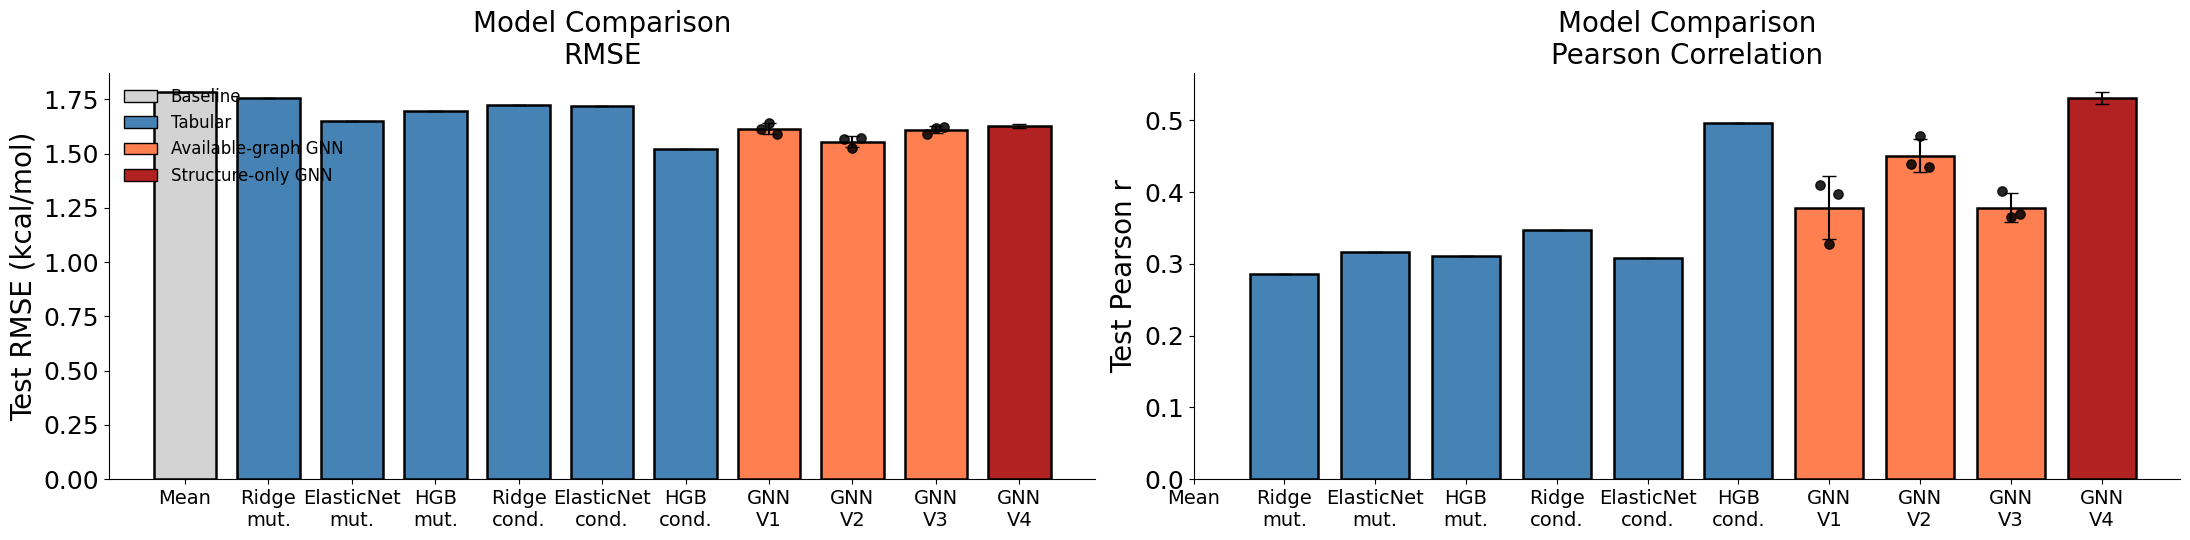

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(22, 5.5))

model_order = [
    "Mean baseline",
    "Ridge (mutation_only)",
    "ElasticNet (mutation_only)",
    "HistGradientBoosting (mutation_only)",
    "Ridge (condition_aware)",
    "ElasticNet (condition_aware)",
    "HistGradientBoosting (condition_aware)",
    "V1 local_delta available-graph GNN",
    "V2 local_delta + condition feats available-graph GNN",
    "V3 local + global + condition feats available-graph GNN",
    "V4 structure-only distance-aware GNN",
]

label_map = {
    "Mean baseline": "Mean",
    "Ridge (mutation_only)": "Ridge\nmut.",
    "ElasticNet (mutation_only)": "ElasticNet\nmut.",
    "HistGradientBoosting (mutation_only)": "HGB\nmut.",
    "Ridge (condition_aware)": "Ridge\ncond.",
    "ElasticNet (condition_aware)": "ElasticNet\ncond.",
    "HistGradientBoosting (condition_aware)": "HGB\ncond.",
    "V1 local_delta available-graph GNN": "GNN\nV1",
    "V2 local_delta + condition feats available-graph GNN": "GNN\nV2",
    "V3 local + global + condition feats available-graph GNN": "GNN\nV3",
    "V4 structure-only distance-aware GNN": "GNN\nV4",
}

family_colors = {
    "baseline": "lightgray",
    "tabular": "steelblue",
    "available_graph_gnn": "coral",
    "structure_gnn": "firebrick",
}

plot_df = model_comparison.copy()
plot_df = plot_df[plot_df["model"].isin(model_order)].copy()
plot_df["order"] = plot_df["model"].map({m: i for i, m in enumerate(model_order)})
plot_df = plot_df.sort_values("order").reset_index(drop=True)

x = np.arange(len(plot_df))
bar_colors = [family_colors.get(f, "gray") for f in plot_df["family"]]
xticklabels = [label_map.get(m, m) for m in plot_df["model"]]

# ── Panel A: Test RMSE ───────────────────────────────────────
ax = axes[0]

ax.bar(
    x,
    plot_df["test_rmse_mean"],
    yerr=plot_df["test_rmse_std"].fillna(0),
    color=bar_colors,
    edgecolor="black",
    linewidth=1.8,
    width=0.75,
    capsize=5,
)

# overlay individual GNN seed points
if "gnn_seed_results" in globals():
    gnn_x_lookup = {m: i for i, m in enumerate(plot_df["model"])}
    for model_name, group in gnn_seed_results.groupby("version"):
        if model_name not in gnn_x_lookup:
            continue
        xpos = gnn_x_lookup[model_name]
        jitter = np.linspace(-0.10, 0.10, len(group))
        ax.scatter(
            xpos + jitter,
            group["test_rmse"],
            color="black",
            s=45,
            zorder=5,
            alpha=0.85,
        )

ax.set_xticks(x)
ax.set_xticklabels(xticklabels, fontsize=14)
ax.set_ylabel("Test RMSE (kcal/mol)", fontsize=20)
ax.set_title("Model Comparison\nRMSE", fontsize=20)
ax.tick_params(axis="y", labelsize=18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── Panel B: Test Pearson r ──────────────────────────────────
ax = axes[1]

ax.bar(
    x,
    plot_df["test_r_mean"],
    yerr=plot_df["test_r_std"].fillna(0),
    color=bar_colors,
    edgecolor="black",
    linewidth=1.8,
    width=0.75,
    capsize=5,
)

# overlay individual GNN seed points
if "gnn_seed_results" in globals():
    gnn_x_lookup = {m: i for i, m in enumerate(plot_df["model"])}
    for model_name, group in gnn_seed_results.groupby("version"):
        if model_name not in gnn_x_lookup:
            continue
        xpos = gnn_x_lookup[model_name]
        jitter = np.linspace(-0.10, 0.10, len(group))
        ax.scatter(
            xpos + jitter,
            group["test_r"],
            color="black",
            s=45,
            zorder=5,
            alpha=0.85,
        )

ax.set_xticks(x)
ax.set_xticklabels(xticklabels, fontsize=14)
ax.set_ylabel("Test Pearson r", fontsize=20)
ax.set_title("Model Comparison\nPearson Correlation", fontsize=20)
ax.tick_params(axis="y", labelsize=18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── Shared legend ────────────────────────────────────────────
from matplotlib.patches import Patch

legend_handles = [
    Patch(facecolor="lightgray", edgecolor="black", label="Baseline"),
    Patch(facecolor="steelblue", edgecolor="black", label="Tabular"),
    Patch(facecolor="coral", edgecolor="black", label="Available-graph GNN"),
    Patch(facecolor="firebrick", edgecolor="black", label="Structure-only GNN"),
]

axes[0].legend(handles=legend_handles, fontsize=12, frameon=False, loc="upper left")

plt.tight_layout()
plt.show()

### 3. Prediction behavior: best tabular model vs best GNN
This shows whether the models are learning the full ΔΔG range or shrinking predictions toward the mean.


### 4. GNN architecture/readout ablation
Which additions to the GNN helped: condition features, global graph pooling, or structure-only filtering?

### 5. Training curves

### 6. Structural-context ablation: buried vs exposed residues
Does graph structure help more for buried residues, where contact networks should matter most?

### 7. Contact graph explorer
TESTING